# Visitor analytics

Two questions on the `visits` table of `visitor_analytics_20260526.sqlite3`:

1. Cumulative number of unique visitors over time.
2. Average number of unique visitors per ISO week.

**Visitor identity.** Each row in `visits` carries an `anonymous_visitor_id` (cookie UUID). The pre-aggregated `visitor_summary` table keys visitors as `cookie:<anonymous_visitor_id>` and contains only `cookie:`-prefixed rows, so a cookie UUID is sufficient as a unique-visitor key here. We use it directly.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = "visitor_analytics_20260526.sqlite3"  # adjust if needed

# Read visits; parse visited_at as tz-aware datetimes (ISO-8601 with +00:00 offset).
with sqlite3.connect(DB_PATH) as con:
    visits = pd.read_sql_query(
        "SELECT anonymous_visitor_id, visited_at FROM visits",
        con,
        parse_dates=["visited_at"],
    )

# Quick sanity check: any null visitor IDs?
assert visits["anonymous_visitor_id"].notna().all(), "unexpected null visitor IDs"

print(f"{len(visits):,} visits, {visits['anonymous_visitor_id'].nunique():,} unique visitors")
print(f"range: {visits['visited_at'].min()}  →  {visits['visited_at'].max()}")

551 visits, 397 unique visitors
range: 2026-03-23 17:33:26+00:00  →  2026-05-26 13:47:05+00:00


## 1. Cumulative unique visitors

For each visitor, take the timestamp of their **first** visit. Sort, then the cumulative count of first-visits = the cumulative count of unique visitors seen up to that point.

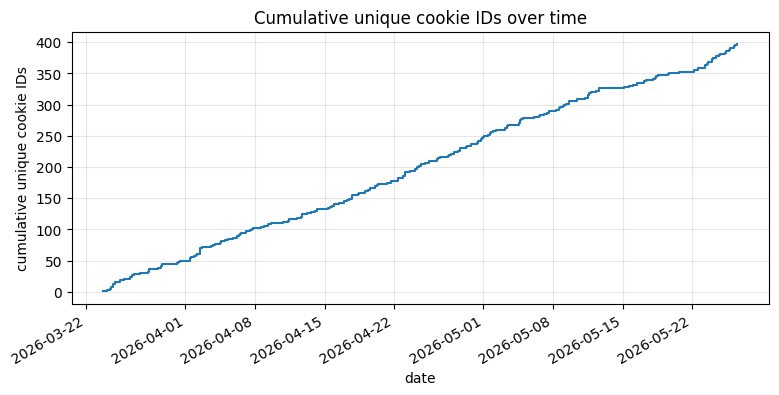

final cumulative total: 397


In [6]:
# First-seen timestamp per visitor; sorting gives the order in which uniques arrive.
first_seen = (
    visits.groupby("anonymous_visitor_id")["visited_at"].min().sort_values()
)

# Cumulative count: each new visitor adds exactly 1 to the running total.
cumulative = pd.Series(range(1, len(first_seen) + 1), index=first_seen.values, name="cumulative_unique")

fig, ax = plt.subplots(figsize=(9, 4))
ax.step(cumulative.index, cumulative.values, where="post")
ax.set_xlabel("date")
ax.set_ylabel("cumulative unique cookie IDs")
ax.set_title("Cumulative unique cookie IDs over time")
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.show()

fig.savefig("cumulative_unique_visitors.png", dpi=300, bbox_inches="tight")

print(f"final cumulative total: {cumulative.iloc[-1]:,}")

## 2. Average unique visitors per week

Bin each visit into its ISO week (Mon–Sun), count distinct visitors per week, then average across weeks. A visitor seen in two different weeks counts once in each — "unique per week," not "unique overall."

In [3]:
# 'W' = weekly periods anchored on Sunday by default in pandas; use 'W-SUN' explicitly
# so the week label is the Sunday end-date (matches ISO Mon–Sun convention).
weekly_uniques = (
    visits.assign(week=visits["visited_at"].dt.to_period("W-SUN"))
          .groupby("week")["anonymous_visitor_id"]
          .nunique()
          .rename("unique_visitors")
)

weekly_uniques

/var/folders/dv/56s67skd7dz1xjmq5t4jybch0000gn/T/ipykernel_30696/397394638.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  visits.assign(week=visits["visited_at"].dt.to_period("W-SUN"))


week
2026-03-23/2026-03-29    45
2026-03-30/2026-04-05    48
2026-04-06/2026-04-12    43
2026-04-13/2026-04-19    48
2026-04-20/2026-04-26    52
2026-04-27/2026-05-03    60
2026-05-04/2026-05-10    48
2026-05-11/2026-05-17    32
2026-05-18/2026-05-24    51
2026-05-25/2026-05-31    19
Freq: W-SUN, Name: unique_visitors, dtype: int64

In [4]:
mean_per_week = weekly_uniques.mean()
print(f"average unique visitors per week: {mean_per_week:.1f}")
print(f"  median: {weekly_uniques.median():.1f}")
print(f"  min / max: {weekly_uniques.min()} / {weekly_uniques.max()}")
print(f"  n weeks: {len(weekly_uniques)}")

# Note: the first and last weeks in the range are partial weeks (the data
# starts mid-week and ends mid-week), so they may pull the mean down. If you
# want the mean over complete weeks only, drop the endpoints:
complete = weekly_uniques.iloc[1:-1]
print(f"\naverage over complete weeks only (n={len(complete)}): {complete.mean():.1f}")

average unique visitors per week: 44.6
  median: 48.0
  min / max: 19 / 60
  n weeks: 10

average over complete weeks only (n=8): 47.8


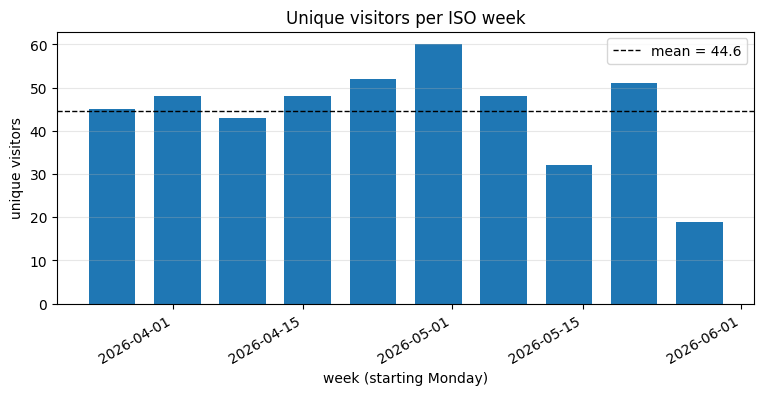

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
# Use week start (Monday) as the x-axis label; .start_time gives a Timestamp.
ax.bar([w.start_time for w in weekly_uniques.index],
       weekly_uniques.values, width=5, align="edge")
ax.axhline(mean_per_week, color="k", linestyle="--", linewidth=1,
           label=f"mean = {mean_per_week:.1f}")
ax.set_xlabel("week (starting Monday)")
ax.set_ylabel("unique visitors")
ax.set_title("Unique visitors per ISO week")
ax.legend()
ax.grid(alpha=0.3, axis="y")
fig.autofmt_xdate()
fig.savefig("weekly_unique_visitors.png", dpi=300, bbox_inches="tight")
plt.show()